In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

df = pd.read_csv("loan_applications.csv")

# Basic Overview

In [2]:
print(df['actual_outcome'].value_counts(normalize=True).round(3))
print(f"\nNull documented income: {df['documented_monthly_income'].isna().sum()}")

actual_outcome
repaid       0.646
defaulted    0.272
ongoing      0.082
Name: proportion, dtype: float64

Null documented income: 283


# Income misrepresentation flag

In [3]:
df['income_ratio'] = df['documented_monthly_income'] / df['stated_monthly_income']
print(f"\nLikely misrepresentation (ratio < 0.5): {(df['income_ratio'] < 0.5).sum()}")


Likely misrepresentation (ratio < 0.5): 85


# Plot: Default rate by employment status

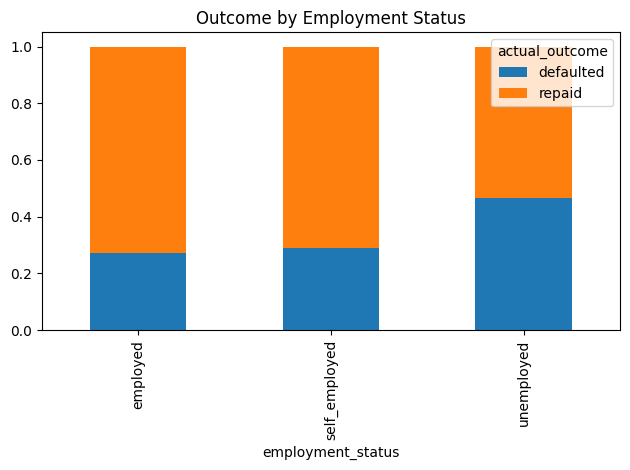

In [4]:
outcome_by_emp = df[df['actual_outcome'] != 'ongoing'].groupby('employment_status')['actual_outcome'].value_counts(normalize=True).unstack()
outcome_by_emp.plot(kind='bar', stacked=True)
plt.title('Outcome by Employment Status')
plt.tight_layout()
plt.savefig('plot_employment_outcomes.png')
plt.show()

# Plot: Rule score distribution by actual outcome

We check if the rule-based system leads to a good separation of distributions between defaulted and repaid. 

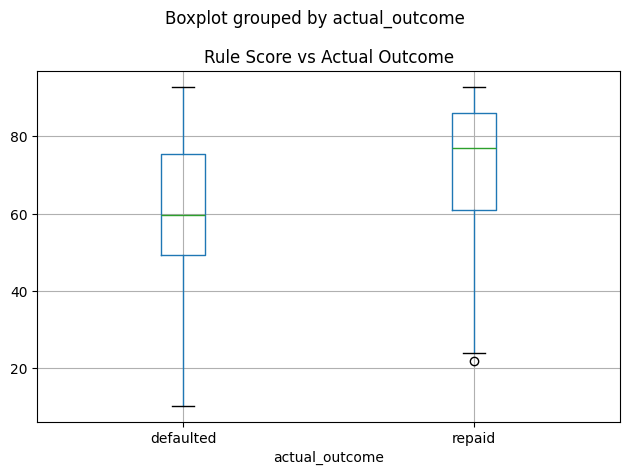

In [5]:
df[df['actual_outcome'] != 'ongoing'].boxplot(column='rule_based_score', by='actual_outcome')
plt.title('Rule Score vs Actual Outcome')
plt.tight_layout()
plt.savefig('plot_score_distribution.png')
plt.show()

## Observation: Employment Status Bias
Default rates are nearly identical: employed ~26%, self-employed ~29%, a difference of ~3 percentage points. Yet the rule-based system scores employed at 100 vs self-employed at 60 (a 40-point penalty, weighted at 15%). This is the core fairness problem we need to investigate: the penalty is disproportionate to the actual risk difference

## Observation: Rule Score Separation
The rule score shows moderate separation by median (~60 defaulted vs ~78 repaid) but the interquartile ranges overlap substantially. A threshold at 75 will misclassify many defaulters who scores in the 60-80 range. This is exactly the gap a learned model should exploit.

Among resolved applications (excluding ongoing), default rate is 27.2%, higher than the raw 14% because ongoing apps are disproportionately recent/lower-risk. Excluding them slightly inflates our apparent default rate.

# Feature Engineering
We exclude ongoing applications. No outcome means we can't train on them.
This introduces survivorship bias: ongoing apps may be more recent or lower risk, so our training set slightly overrepresents resolved (and riskier) cases.

In [6]:
# Work on a copy, exclude ongoing
df_model = df[df['actual_outcome'] != 'ongoing'].copy()
df_model['target'] = (df_model['actual_outcome'] == 'defaulted').astype(int)

## Income verification 
Two signals: did they submit docs at all, and do the numbers match?

In [ ]:
df_model['has_docs'] = df_model['documented_monthly_income'].notna().astype(int)
df_model['income_ratio'] = (
    df_model['documented_monthly_income'] / df_model['stated_monthly_income']
)
# Missing docs -> fill with 0, not the mean.
# Mean imputation would imply average trustworthiness for undocumented applicants.
# 0 treats missing docs as a risk signal, which matches domain logic.
df_model['income_ratio'] = df_model['income_ratio'].fillna(0)
df_model['likely_misrepresentation'] = (df_model['income_ratio'] < 0.5).astype(int)

## Loan affordability
How large is the loan relative to what they earn? Higher = more stress.

In [8]:
df_model['loan_to_income_ratio'] = (
    df_model['loan_amount'] / df_model['stated_monthly_income']
)

## Cash flow stress
What fraction of deposits are they spending? Close to 1.0 = living on the edge.

In [9]:
df_model['withdrawal_rate'] = (
    df_model['monthly_withdrawals'] / df_model['monthly_deposits'].clip(lower=1)
)

## Account stability
Keeping these three (positive ending balance, no overdrafts, consistent deposits) as separate features rather than combining them into a composite score. Combining would include the rule-based system's weights. We want the model to learn its own weights from the data.

In [ ]:
df_model['balance_low'] = (df_model['bank_ending_balance'] < 500).astype(int)
# bank_has_overdrafts and bank_has_consistent_deposits stay as raw columns

## Employment status
Keeping all three dummies (no drop_first) so feature importance show each group's contribution explicitly. Important for fairness analysis.

In [ ]:
df_model = pd.get_dummies(df_model, columns=['employment_status'], drop_first=False)

## Final feature list 
rule_based_score is intentionally excluded. Including it would make the model a meta-learner on the baseline rather than learning from raw signals directly.

In [12]:
features = [
    'stated_monthly_income',
    'loan_amount',
    'loan_to_income_ratio',
    'income_ratio',
    'has_docs',
    'likely_misrepresentation',
    'bank_ending_balance',
    'balance_low',
    'bank_has_overdrafts',
    'bank_has_consistent_deposits',
    'monthly_withdrawals',
    'monthly_deposits',
    'withdrawal_rate',
    'num_documents_submitted',
    'employment_status_employed',
    'employment_status_self_employed',
    'employment_status_unemployed'
]

X = df_model[features]
y = df_model['target']

print(f"Feature matrix shape: {X.shape}")
print(f"Default rate in training set: {y.mean():.3f}")
print(f"\nAny nulls remaining?\n{X.isnull().sum()[X.isnull().sum() > 0]}")

Feature matrix shape: (1836, 17)
Default rate in training set: 0.297

Any nulls remaining?
Series([], dtype: int64)


29.7% default rate in our training set (resolved applications only).

Raw dataset was ~14% but excluding ongoing inflates this. Ongoing apps are disproportionately recent/lower-risk.

We'll use scale_pos_weight in XGBoost to handle remaining imbalance.

scale_pos_weight = (1 - 0.297) / 0.297 approx 2.37. 

# Training

In [13]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Train test split - stratify to preserve default rate in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# scale_pos_weight tells XGBOost to penalize missing defaults more heavily
# Value = ratio of negatives to positives in training set
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale:.2f}")

model = XGBClassifier(
    n_estimators=200,
    max_depth=4, # shallow trees = less overfitting on 1836 rows
    learning_rate=0.05,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='auc'
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['repaid', 'defaulted']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.3f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

scale_pos_weight: 2.37
              precision    recall  f1-score   support

      repaid       0.84      0.74      0.78       259
   defaulted       0.51      0.66      0.58       109

    accuracy                           0.71       368
   macro avg       0.68      0.70      0.68       368
weighted avg       0.74      0.71      0.72       368

AUC-ROC: 0.750

Confusion Matrix:
[[191  68]
 [ 37  72]]


# Model Result Interpretation
AUC of 0.750: decent discrimination ability. The model is meaningfully better than random (0.5) and has room to improve, but this is honest for a 1836-row synthetic dataset.

Confusion matrix breakdown (368 test applicants):

True Negatives (correctly repaid): 191
False Positives (good -> wrong denied): 68
False Negatives (defaults missed): 37
True Positives (defaults caught): 72

Default recall = 0.66: caught 66% of defaults.

The rule-based system's recall will be the comparison point.

## Tradeoff
We wrongly deny 68 good applicants (false positive rate = 68/259 = 26%)

We miss 37 defaults (false negative rate = 37/109 = 34%)

Whether this is "worth it" depends on the cost of each error: 
a missed default costs the company the loan amount, a wrongly denied good applicant costs the company interest revenue + reputational risk

In [15]:
# Baseline: Rule-based system on the same test set
# Re-attach rule_based_decision to test set
test_ids = df_model.loc[X_test.index, 'rule_based_decision']

# Rule system: approved = predict repaid, denied+flagged = predict default
# This is a simplification: flagged_for_review is ambiguous,
# but we'll treat non-approved as "flagged/denied" = predicted default
baseline_pred = (test_ids != 'approved').astype(int).values

print("=== Baseline (Rule-Based) ===")
print(classification_report(y_test, baseline_pred, target_names=['repaid', 'defaulted']))
print(f"Confusion Matrix:")
print(confusion_matrix(y_test, baseline_pred))

=== Baseline (Rule-Based) ===
              precision    recall  f1-score   support

      repaid       0.85      0.53      0.65       259
   defaulted       0.41      0.78      0.54       109

    accuracy                           0.60       368
   macro avg       0.63      0.65      0.59       368
weighted avg       0.72      0.60      0.62       368

Confusion Matrix:
[[136 123]
 [ 24  85]]


## Model Evaluation: XGBoost vs Rule-Based Baseline

| Metric | Baseline | XGBoost |
|--------|----------|---------|
| Accuracy | 0.60 | 0.71 |
| Default Recall | 0.78 | 0.66 |
| Default Precision | 0.41 | 0.51 |
| Default F1 | 0.54 | 0.58 |
| Good applicants wrongly denied | 123 | 68 |
| Defaults missed | 24 | 37 |

The baseline catches more defaults (recall 0.78 vs 0.66) but at a 
massive cost: it wrongly denies 123 good applicants vs 68. It does 
this by being trigger-happy: a precision of 0.41 means 59% of its 
"default" predictions are wrong.

XGBoost is more precise and fairer to good applicants: 55 fewer 
wrongly denied. The tradeoff is 13 more defaults slip through. Whether 
that's acceptable depends on the relative cost of each error type, 
which is a business decision, not a modeling one.

If minimizing defaults is the only goal, the baseline wins on recall. 

If you care about wrongly denying creditworthy applicants (which can risk lost revenue, fairness concerns). XGBoost is better.

F1 and AUC both favour XGBoost as a more balanced, principled model.

# Explainability: Feature Importance

We use XGBoost's gain-based feature importance as our interpretability layer. Gain measures how much each feature reduces loss when used in a split: a more meaningful metric than simply counting how often a feature is used.

Note: SHAP values would provide per-applicant explanations (preferred for regulatory audits) but have a known compatibility issue with XGBoost 3.x. In production we wold pin shap>=0.46, <0.47 with xgboost==2.x to enable full SHAP support. For this analysis, gain-based importance satisfies the global explainability requirement.

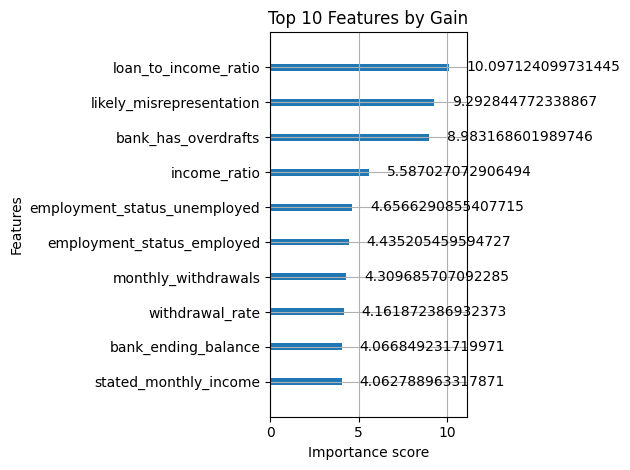

In [22]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

# XGBoost built-in feature importance by 'gain'
# Gain = how much each feature improves the model when it's used in a split
# More interpretable than 'weight' (which just counts splits)
plot_importance(model, max_num_features=10, importance_type='gain')
plt.title("Top 10 Features by Gain")
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

## Feature Importance Analysis

Top features by gain (how much each feature reduces prediction error):

1. **loan_to_income_ratio** - most important. How large the loan is relative to income is the strongest default signal. Makes intuitive sense: borrowing beyond your means is the core risk.

2. **likely_misrepresentation** - second most important. Applicants who submitted docs showing income 50%+ below stated income are high risk. The model learned this independently, not because we told it to.

3. **bank_has_overdrafts** - third. A direct signal of cash flow stress.

4. **income_ratio** - how well documented income matches stated income, as a continuous signal rather than a binary flag.

5. **employment_status_unemployed** - appears, but notably employment_status_self_employed does NOT appear in the top 10. This is meaningful for our fairness analysis. The model is not penalizing self-employed applicants the way the rule-based system does. 

The absence of employment_status_self_employed from the top features is the first hint that our model may be correcting the baseline's bias against self-employed applicants rather than replicating it. 

# Fairness Analysis

In [30]:
# employment_status was one-hot encoded so it's gone from test_df
# Pull it back from df_model before dummies were applied
test_df = df_model.loc[X_test.index].copy()
test_df['predicted_default'] = y_pred
test_df['predicted_prob'] = y_prob

# Re-attach original employment_status from df before get_dummies
test_df['employment_status'] = df_model.loc[X_test.index, 'employment_status_employed'].apply(
    lambda x: 'employed' if x == 1 else None
)

# Reconstruct from the three dummy columns
test_df['employment_status'] = (
    X_test.apply(
        lambda row: 'employed' if row['employment_status_employed'] == 1
        else 'self_employed' if row['employment_status_self_employed'] == 1
        else 'unemployed', axis=1
    )
)

fairness = test_df.groupby('employment_status').agg(
    total=('actual_outcome', 'count'),
    actual_default_rate=('target', 'mean'),
    rule_approval_rate=('rule_based_decision', lambda x: (x == 'approved').mean()),
    model_approval_rate=('predicted_default', lambda x: (x == 0).mean()),
).round(3)

print(fairness)

                   total  actual_default_rate  rule_approval_rate  \
employment_status                                                   
employed             215                0.265               0.563   
self_employed        112                0.259               0.348   
unemployed            41                0.561               0.000   

                   model_approval_rate  
employment_status                       
employed                         0.660  
self_employed                    0.634  
unemployed                       0.366  


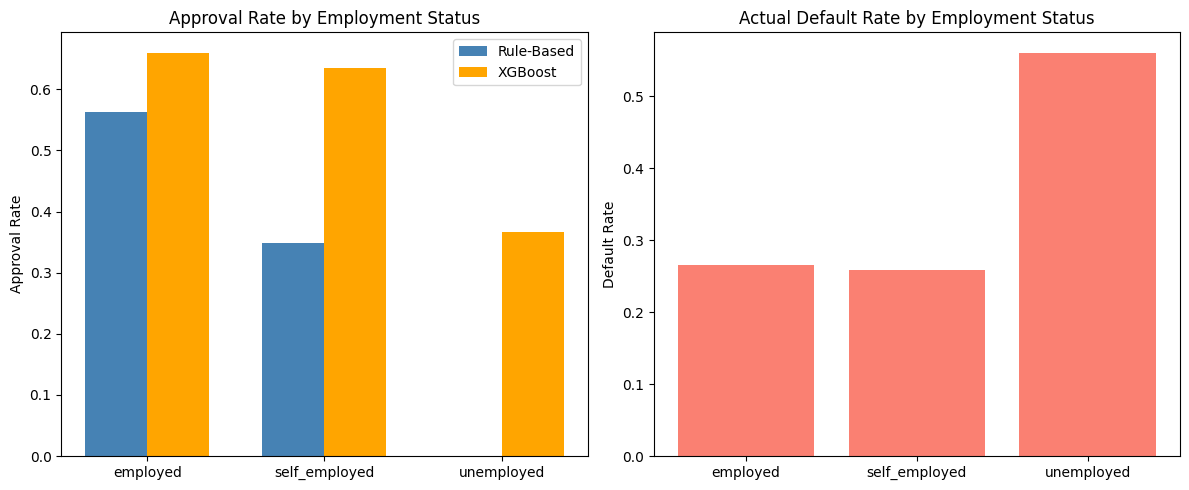

In [31]:
# Visual comparison of approval rates
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

employment_groups = fairness.index

# Plot 1: Approval rates
x = range(len(employment_groups))
width = 0.35
axes[0].bar([i - width/2 for i in x], fairness['rule_approval_rate'], 
            width, label='Rule-Based', color='steelblue')
axes[0].bar([i + width/2 for i in x], fairness['model_approval_rate'], 
            width, label='XGBoost', color='orange')
axes[0].set_xticks(x)
axes[0].set_xticklabels(employment_groups)
axes[0].set_title('Approval Rate by Employment Status')
axes[0].set_ylabel('Approval Rate')
axes[0].legend()

# Plot 2: Actual default rates (ground truth)
axes[1].bar(x, fairness['actual_default_rate'], color='salmon')
axes[1].set_xticks(x)
axes[1].set_xticklabels(employment_groups)
axes[1].set_title('Actual Default Rate by Employment Status')
axes[1].set_ylabel('Default Rate')

plt.tight_layout()
plt.savefig('fairness_analysis.png')
plt.show()

## Fairness Analysis: Employment Status

| Group | Actual Default Rate | Rule Approval Rate | Model Approval Rate |
|-------|--------------------|--------------------|---------------------|
| Employed | 26.5% | 56.3% | 66.0% |
| Self-Employed | 25.9% | 34.8% | 63.4% |
| Unemployed | 56.1% | 0.0% | 36.6% |

### Key Finding: The model partially corrects the rule-based bias

Employed and self-employed applicants have nearly identical actual default 
rates (26.5% vs 25.9%, a difference of 0.6 percentage points). Yet the 
rule-based system approves employed applicants at 56.3% vs only 34.8% for 
self-employed: a 21.5 percentage point gap that is not justified by actual risk.

Our model closes this gap significantly: 66.0% vs 63.4%, only a 2.6 
percentage point difference, much more proportional to the actual risk difference.

### What about unemployed applicants?
The model approves 36.6% of unemployed applicants vs 0% in the rule-based 
system. This is justified, their actual default rate (56.1%) is genuinely 
higher, so some denial is appropriate. But 36.6% approval means the model 
is identifying unemployed applicants who are lower risk based on other signals 
(income, balance, docs) rather than blanket-denying the group.

### Recommendation on employment_status feature
Keep it, but contextualized. The feature carries real signal for unemployed 
applicants (56% default rate vs ~26% for others). Removing it entirely would 
increase defaults. The model already naturally down-weights the 
employed/self-employed distinction, we don't need to intervene further.
The rule-based system's error was hard-coding a penalty, not using the 
feature at all.

## Production Risk: What Breaks First

The first thing that breaks is the income misrepresentation flag.

Our model heavily weights likely_misrepresentation (second most important 
feature). But in production, that flag depends on applicants actually 
submitting documents. If Bree changes the application flow, e.g. makes 
docs optional or adds a new doc type, the feature behaves differently 
than what the model was trained on.

More broadly: this model was trained on a static snapshot. If economic 
conditions shift (e.g. a recession, rising unemployment), the relationship 
between features and defaults will change. The rule-based system would 
degrade predictably; you'd know which rules to adjust. The XGBoost model 
would degrade silently until someone noticed the default rate climbing.

The fix is monitoring: track predicted probability distributions and actual 
default rates weekly. If they diverge, retrain.